# 07 - Cuantificacion de Incertidumbre (Dual Target)

## Objetivo

Construir **intervalos de prediccion** calibrados para **ambos targets** (price y price_m2) usando Conformalized Quantile Regression (CQR).

### Que hacemos aqui

1. **Regresion cuantilica**: Entrenamos modelos P5/P50/P95 para cada target.
2. **Calibracion conformal (CQR)**: Ajustamos intervalos con cobertura objetivo del 85%.
3. **Clipping P50**: Garantizamos P5 <= P50 <= P95 (correccion de crossing completo).
4. **Validacion en holdout**: Verificamos cobertura en datos nunca vistos.

### Entradas

| Artefacto | Descripcion |
|---|---|
| `artifacts/features_master.parquet` | Features numericas del pipeline |
| `artifacts/splits/holdout_indices.npz` | Indices de train/holdout |

### Salidas

| Artefacto | Descripcion |
|---|---|
| `models/quantile_models.joblib` | Modelos cuantilicos dual target + CQR |
| `reports/uncertainty_metrics.csv` | Metricas de cobertura y anchura por target |

In [6]:
from __future__ import annotations
from pathlib import Path
import sys

import numpy as np
import pandas as pd

# Semilla global para reproducibilidad (garantiza resultados identicos en cada ejecucion)
SEED = 100432070
np.random.seed(SEED)

def get_repo_root() -> Path:
    """Localiza la raiz del repositorio buscando .git o pyproject.toml en directorios padre."""
    current = Path.cwd().resolve()
    for parent in [current] + list(current.parents):
        if (parent / ".git").exists() or (parent / "pyproject.toml").exists():
            return parent
    return current

# Configuracion de rutas del proyecto
ROOT = get_repo_root()
if str(ROOT) not in sys.path:
    # Anade src/ al path para poder importar utilidades propias del proyecto
    sys.path.append(str(ROOT))

from src.utils import eval_regression, get_feature_cols, TARGET_COLS, DERIVED_FROM_TARGET, ID_COLS

---

## 1. Configuracion del Entorno

Cargamos las librerias necesarias y establecemos la **semilla de reproducibilidad** para que cualquier persona pueda ejecutar este notebook y obtener exactamente los mismos resultados.

In [7]:
import json
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingRegressor
import joblib

# =====================================================================
# 1. CARGA DE DATOS
# =====================================================================
features_path = ROOT / "artifacts" / "features_master.parquet"
if features_path.exists():
    df = pd.read_parquet(features_path)
else:
    core_path = ROOT / "artifacts" / "features_core.parquet"
    if core_path.exists():
        df = pd.read_parquet(core_path)
    else:
        df = pd.read_csv(ROOT / "artifacts" / "features_core.csv.gz")

split = np.load(ROOT / "artifacts" / "splits" / "holdout_indices.npz")
train_idx, test_idx = split["train_idx"], split["test_idx"]

feature_cols = get_feature_cols(df, numeric_only=True)
X = df[feature_cols].replace([np.inf, -np.inf], np.nan)
print(f"Features numéricas: {len(feature_cols)}")

# --- Filtrar por features seleccionadas si existen ---
sel_path = ROOT / "artifacts" / "selected_features.json"
if sel_path.exists():
    _sel = json.loads(sel_path.read_text(encoding="utf-8"))
    _all_selected = set()
    for _t in _sel:
        if isinstance(_sel[_t], dict) and "selected" in _sel[_t]:
            _all_selected.update(_sel[_t]["selected"])
    if _all_selected:
        feature_cols = [c for c in feature_cols if c in _all_selected]
        X = df[feature_cols].replace([np.inf, -np.inf], np.nan)
        print(f"Feature selection activa: {len(feature_cols)} features")

# =====================================================================
# 2. DUAL TARGET LOOP
# =====================================================================
TARGETS = {"price": "price", "price_m2": "price_m2"}
alpha = 0.15  # Objetivo: 85% de cobertura
all_reports = []
dual_quantile_artifact = {}
viz_data = {}  # Per-target viz data

for target_name, target_col in TARGETS.items():
    if target_col not in df.columns:
        print(f"\nSKIP target={target_name}: columna no encontrada")
        continue

    print(f"\n{'='*60}")
    print(f"UNCERTAINTY: {target_name}")
    print(f"{'='*60}")

    y = df[target_col].replace([np.inf, -np.inf], np.nan)
    unit = "EUR/mes" if target_name == "price" else "EUR/m2"

    # Particion train/holdout
    X_train_full = X.loc[train_idx]
    y_train_full = y.loc[train_idx]
    X_holdout = X.loc[test_idx]
    y_holdout = y.loc[test_idx]

    train_mask = np.isfinite(y_train_full)
    X_train_full = X_train_full.loc[train_mask]
    y_train_full = y_train_full.loc[train_mask]

    holdout_mask = np.isfinite(y_holdout)
    X_holdout = X_holdout.loc[holdout_mask]
    y_holdout = y_holdout.loc[holdout_mask]

    if len(X_train_full) < 50:
        print(f"  SKIP: solo {len(X_train_full)} muestras validas")
        continue

    # Split interno: 80% train, 20% calibracion
    X_train, X_cal, y_train, y_cal = train_test_split(
        X_train_full, y_train_full, test_size=0.2, random_state=SEED
    )
    print(f"  Train: {len(X_train)}, Cal: {len(X_cal)}, Holdout: {len(X_holdout)}")

    # --- Entrenar modelos cuantilicos ---
    models = {
        0.05: HistGradientBoostingRegressor(loss="quantile", quantile=0.05, random_state=SEED),
        0.5: HistGradientBoostingRegressor(loss="quantile", quantile=0.5, random_state=SEED),
        0.95: HistGradientBoostingRegressor(loss="quantile", quantile=0.95, random_state=SEED),
    }
    for m in models.values():
        m.fit(X_train, y_train)

    # --- Predicciones en calibracion ---
    preds_cal = {q: m.predict(X_cal) for q, m in models.items()}

    # Correccion de quantile crossing completa: P5 <= P50 <= P95
    lo = np.minimum(preds_cal[0.05], preds_cal[0.95])
    hi = np.maximum(preds_cal[0.05], preds_cal[0.95])
    preds_cal[0.05] = lo
    preds_cal[0.95] = hi
    preds_cal[0.5] = np.clip(preds_cal[0.5], preds_cal[0.05], preds_cal[0.95])

    assert np.all(preds_cal[0.05] <= preds_cal[0.5]), "P5 > P50 tras correccion"
    assert np.all(preds_cal[0.5] <= preds_cal[0.95]), "P50 > P95 tras correccion"

    coverage_cal = ((y_cal >= preds_cal[0.05]) & (y_cal <= preds_cal[0.95])).mean()
    width_cal = (preds_cal[0.95] - preds_cal[0.05]).mean()

    # --- CQR raw ---
    err = np.maximum(preds_cal[0.05] - y_cal, y_cal - preds_cal[0.95])
    err = err[~np.isnan(err)]
    qhat = np.quantile(err, min(1.0, np.ceil((len(err) + 1) * (1 - alpha)) / len(err))) if len(err) > 0 else 0.0

    cal_low_adj_raw = preds_cal[0.05] - qhat
    cal_high_adj_raw = preds_cal[0.95] + qhat
    coverage_cal_adj_raw = ((y_cal >= cal_low_adj_raw) & (y_cal <= cal_high_adj_raw)).mean()
    width_cal_adj_raw = (cal_high_adj_raw - cal_low_adj_raw).mean()

    # --- CQR log ---
    log_y_cal = np.log1p(np.clip(y_cal, a_min=0, a_max=None))
    log_low = np.log1p(np.clip(preds_cal[0.05], a_min=0, a_max=None))
    log_high = np.log1p(np.clip(preds_cal[0.95], a_min=0, a_max=None))
    err_log = np.maximum(log_low - log_y_cal, log_y_cal - log_high)
    err_log = err_log[~np.isnan(err_log)]
    qhat_log = np.quantile(err_log, min(1.0, np.ceil((len(err_log) + 1) * (1 - alpha)) / len(err_log))) if len(err_log) > 0 else 0.0

    cal_low_adj = np.expm1(log_low - qhat_log)
    cal_high_adj = np.expm1(log_high + qhat_log)
    cal_low_adj = np.clip(cal_low_adj, a_min=0, a_max=None)
    cal_high_adj = np.clip(cal_high_adj, a_min=0, a_max=None)
    coverage_cal_adj = ((y_cal >= cal_low_adj) & (y_cal <= cal_high_adj)).mean()

    # --- Evaluacion holdout ---
    preds_holdout = {q: m.predict(X_holdout) for q, m in models.items()}

    # Correccion crossing completa en holdout: P5 <= P50 <= P95
    lo_h = np.minimum(preds_holdout[0.05], preds_holdout[0.95])
    hi_h = np.maximum(preds_holdout[0.05], preds_holdout[0.95])
    preds_holdout[0.05] = lo_h
    preds_holdout[0.95] = hi_h
    preds_holdout[0.5] = np.clip(preds_holdout[0.5], preds_holdout[0.05], preds_holdout[0.95])

    coverage_holdout = ((y_holdout >= preds_holdout[0.05]) & (y_holdout <= preds_holdout[0.95])).mean()
    width_holdout = (preds_holdout[0.95] - preds_holdout[0.05]).mean()

    hold_low_adj_raw = preds_holdout[0.05] - qhat
    hold_high_adj_raw = preds_holdout[0.95] + qhat
    coverage_holdout_adj_raw = ((y_holdout >= hold_low_adj_raw) & (y_holdout <= hold_high_adj_raw)).mean()
    width_holdout_adj_raw = (hold_high_adj_raw - hold_low_adj_raw).mean()

    log_low_h = np.log1p(np.clip(preds_holdout[0.05], a_min=0, a_max=None))
    log_high_h = np.log1p(np.clip(preds_holdout[0.95], a_min=0, a_max=None))
    hold_low_adj = np.expm1(log_low_h - qhat_log)
    hold_high_adj = np.expm1(log_high_h + qhat_log)
    hold_low_adj = np.clip(hold_low_adj, a_min=0, a_max=None)
    hold_high_adj = np.clip(hold_high_adj, a_min=0, a_max=None)
    coverage_holdout_adj = ((y_holdout >= hold_low_adj) & (y_holdout <= hold_high_adj)).mean()
    width_holdout_adj = (hold_high_adj - hold_low_adj).mean()

    # Seleccion mejor metodo
    best_coverage_holdout = max(coverage_holdout_adj_raw, coverage_holdout_adj)
    best_method = "raw" if coverage_holdout_adj_raw >= coverage_holdout_adj else "log"
    print(f"  Coverage holdout CQR raw: {coverage_holdout_adj_raw:.1%}")
    print(f"  Coverage holdout CQR log: {coverage_holdout_adj:.1%}")
    print(f"  Mejor metodo: {best_method} ({best_coverage_holdout:.1%})")

    target_coverage = 1 - alpha
    if best_coverage_holdout < target_coverage - 0.02:
        print(f"  WARN: Coverage {best_coverage_holdout:.1%} < {target_coverage - 0.02:.0%}")

    # Guardar en artefacto dual
    dual_quantile_artifact[target_name] = {
        "models": models,
        "features": list(X.columns),
        "quantile_levels": [0.05, 0.5, 0.95],
        "conformal": {"alpha": alpha, "qhat": float(qhat)},
        "conformal_log": {"alpha": alpha, "qhat": float(qhat_log), "transform": "log1p"},
        "best_method": best_method,
    }

    all_reports.append({
        "target": target_name,
        "coverage_cal": float(coverage_cal),
        "avg_width_cal": float(width_cal),
        "coverage_cal_adj_raw": float(coverage_cal_adj_raw),
        "coverage_holdout": float(coverage_holdout),
        "coverage_holdout_adj_raw": float(coverage_holdout_adj_raw),
        "avg_width_holdout_adj_raw": float(width_holdout_adj_raw),
        "coverage_holdout_adj_log": float(coverage_holdout_adj),
        "avg_width_holdout_adj_log": float(width_holdout_adj),
        "cqr_qhat_raw": float(qhat),
        "cqr_qhat_log": float(qhat_log),
        "best_method": best_method,
    })

    # Store data for visualization cell
    viz_data[target_name] = {
        "preds_holdout": preds_holdout,
        "y_holdout": y_holdout.values,
        "qhat": qhat,
        "unit": unit,
    }

# =====================================================================
# 3. GUARDAR ARTEFACTOS
# =====================================================================
# Formato dual: {price: {...}, price_m2: {...}}
quantile_path = ROOT / "models" / "quantile_models.joblib"
joblib.dump(dual_quantile_artifact, quantile_path)
print(f"\nModelos cuantilicos guardados: {quantile_path}")
print(f"Targets: {list(dual_quantile_artifact.keys())}")

report_df = pd.DataFrame(all_reports)
report_df.to_csv(ROOT / "reports" / "uncertainty_metrics.csv", index=False)
report_df

Features numéricas: 49

UNCERTAINTY: price
  Train: 5144, Cal: 1287, Holdout: 1772
  Coverage holdout CQR raw: 87.0%
  Coverage holdout CQR log: 87.0%
  Mejor metodo: raw (87.0%)

UNCERTAINTY: price_m2
  Train: 5138, Cal: 1285, Holdout: 1771
  Coverage holdout CQR raw: 87.1%
  Coverage holdout CQR log: 87.1%
  Mejor metodo: raw (87.1%)

Modelos cuantilicos guardados: C:\Users\samuf\Desktop\TFG_SPA_Madrid\models\quantile_models.joblib
Targets: ['price', 'price_m2']


,target,coverage_cal,avg_width_cal,coverage_cal_adj_raw,coverage_holdout,coverage_holdout_adj_raw,avg_width_holdout_adj_raw,coverage_holdout_adj_log,avg_width_holdout_adj_log,cqr_qhat_raw,cqr_qhat_log,best_method
0,price,0.808081,1484.863527,0.850816,0.823928,0.869639,1359.752021,0.869639,1398.122166,27.658350,0.024416,raw
1,price_m2,0.828016,14.959438,0.851362,0.849238,0.871259,14.714998,0.870695,14.862377,0.196542,0.012084,raw


---

## 2. Carga de Datos y Preparacion de Splits

### Estrategia de particion

Dividimos los datos en tres conjuntos con propositos distintos:

- **Train**: para entrenar los modelos cuantilicos
- **Calibracion**: para ajustar los intervalos con CQR (20% del train)
- **Holdout**: datos intocables para evaluacion final

> **Nota sobre leakage**: Excluimos cualquier columna derivada del precio (como `price_m2`, `log_price`) de las features, ya que usarlas seria como "hacer trampa" -- el modelo veria informacion del target.

In [8]:
# Resumen de metricas por target
print("Metricas de incertidumbre guardadas en reports/uncertainty_metrics.csv")
report_df

Metricas de incertidumbre guardadas en reports/uncertainty_metrics.csv


,target,coverage_cal,avg_width_cal,coverage_cal_adj_raw,coverage_holdout,coverage_holdout_adj_raw,avg_width_holdout_adj_raw,coverage_holdout_adj_log,avg_width_holdout_adj_log,cqr_qhat_raw,cqr_qhat_log,best_method
0,price,0.808081,1484.863527,0.850816,0.823928,0.869639,1359.752021,0.869639,1398.122166,27.658350,0.024416,raw
1,price_m2,0.828016,14.959438,0.851362,0.849238,0.871259,14.714998,0.870695,14.862377,0.196542,0.012084,raw


---

### Guardado del reporte de metricas

Exportamos las metricas a CSV para que otros notebooks y el informe final puedan consultarlas sin reejecutar este notebook.

---

## 📊 7. Visualizaciones de Incertidumbre

Dos graficos clave para entender la calidad de nuestros intervalos:

1. **Histograma de anchura de intervalos**: Nos muestra como de dispersos son los rangos de prediccion. Intervalos muy anchos significan poca confianza; intervalos estrechos pero con buena cobertura son ideales.

2. **Scatter predicho vs real con bandas**: Cada punto es un piso del holdout. La linea roja `y=x` representa prediccion perfecta. Las bandas sombreadas muestran el rango P10-P90 real por bins de prediccion.

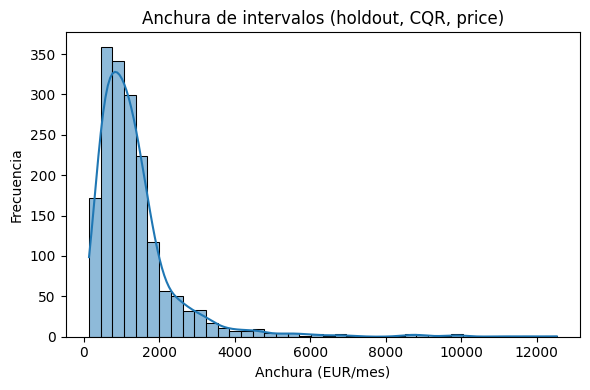

price - limite visual usado: 0 a 8000


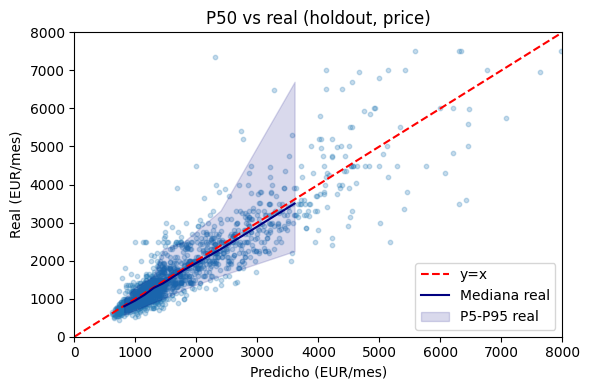

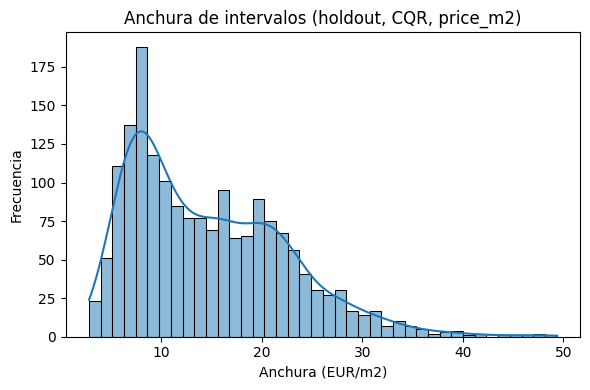

price_m2 - limite visual usado: 0 a 60


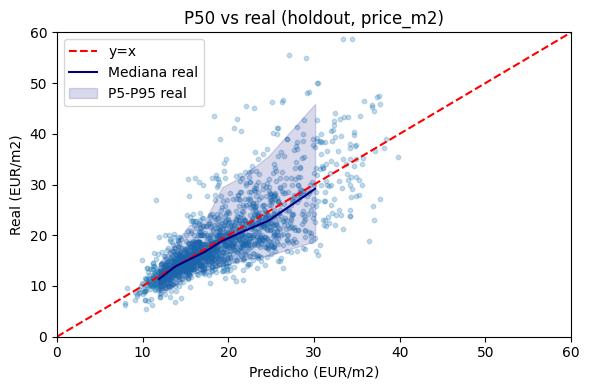

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

(ROOT / "reports" / "figures").mkdir(parents=True, exist_ok=True)

for target_name, vd in viz_data.items():
    preds_h = vd["preds_holdout"]
    y_h = vd["y_holdout"]
    qhat_v = vd["qhat"]
    unit = vd["unit"]

    # --- Grafico 1: Distribucion de anchura de intervalos ---
    interval_low = preds_h[0.05] - qhat_v
    interval_high = preds_h[0.95] + qhat_v
    interval_width = interval_high - interval_low

    plt.figure(figsize=(6, 4))
    sns.histplot(interval_width, bins=40, kde=True)
    plt.title(f"Anchura de intervalos (holdout, CQR, {target_name})")
    plt.xlabel(f"Anchura ({unit})")
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.savefig(
        ROOT / "reports" / "figures" / f"uncertainty_width_{target_name}.png",
        dpi=150,
        bbox_inches="tight"
    )
    plt.show()

    # --- Grafico 2: Prediccion P50 vs real con zoom controlado ---
    pred_series = pd.Series(preds_h[0.5], name="pred")
    real_series = pd.Series(y_h, name="real")
    plot_df = pd.DataFrame({"pred": pred_series, "real": real_series}).dropna()

    # Limites visuales fijos
    if target_name == "price":
        lower_lim = 0
        upper_lim = 8000
    elif target_name == "price_m2":
        lower_lim = 0
        upper_lim = 60
    else:
        lower_lim = 0
        upper_lim = float(
            np.nanquantile(plot_df[["pred", "real"]].to_numpy().ravel(), 0.99)
        )

    print(f"{target_name} - limite visual usado: {lower_lim} a {upper_lim}")

    # Filtramos SOLO para visualizacion
    plot_df_vis = plot_df[
        (plot_df["pred"] >= lower_lim) &
        (plot_df["pred"] <= upper_lim) &
        (plot_df["real"] >= lower_lim) &
        (plot_df["real"] <= upper_lim)
    ].copy()

    if len(plot_df_vis) == 0:
        print(f"No hay datos para visualizar en {target_name} con esos limites.")
        continue

    bins = min(20, max(6, int(len(plot_df_vis) / 200)))

    plot_df_vis["pred_bin"] = pd.qcut(
        plot_df_vis["pred"],
        q=bins,
        duplicates="drop"
    )

    quantiles = plot_df_vis.groupby("pred_bin", observed=True)["real"].agg(
        p05=lambda x: x.quantile(0.05),
        p50="median",
        p95=lambda x: x.quantile(0.95),
    )

    centers = plot_df_vis.groupby("pred_bin", observed=True)["pred"].median()
    quantiles = quantiles.assign(pred_center=centers.values).sort_values("pred_center")

    plt.figure(figsize=(6, 4))

    plt.scatter(
        plot_df_vis["pred"],
        plot_df_vis["real"],
        alpha=0.25,
        s=10
    )

    plt.plot(
        [lower_lim, upper_lim],
        [lower_lim, upper_lim],
        color="red",
        linestyle="--",
        label="y=x"
    )

    plt.plot(
        quantiles["pred_center"],
        quantiles["p50"],
        color="navy",
        label="Mediana real"
    )

    plt.fill_between(
        quantiles["pred_center"],
        quantiles["p05"],
        quantiles["p95"],
        color="navy",
        alpha=0.15,
        label="P5-P95 real"
    )

    plt.xlim(lower_lim, upper_lim)
    plt.ylim(lower_lim, upper_lim)

    plt.title(f"P50 vs real (holdout, {target_name})")
    plt.xlabel(f"Predicho ({unit})")
    plt.ylabel(f"Real ({unit})")
    plt.legend()
    plt.tight_layout()

    plt.savefig(
        ROOT / "reports" / "figures" / f"uncertainty_scatter_{target_name}_zoom.png",
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

**Outputs esperados**

- Coverage y anchura media del intervalo de prediccion.
- `reports/uncertainty_metrics.csv` actualizado.
- `models/quantile_models.joblib` con calibrador raw y log.


In [10]:
from IPython.display import display, Markdown

# --- Extraer metricas de report_df (calculado en celda anterior) ---
def _rpt(target, col):
    row = report_df[report_df["target"] == target]
    if row.empty or col not in row.columns:
        return 0
    return row.iloc[0][col]

p_cov_ho = _rpt("price", "coverage_holdout_adj_raw") * 100
p_width = _rpt("price", "avg_width_holdout_adj_raw")
p_qhat = _rpt("price", "cqr_qhat_raw")
p_cov_cal = _rpt("price", "coverage_cal_adj_raw") * 100 if "coverage_cal_adj_raw" in report_df.columns else _rpt("price", "coverage_cal") * 100
p_cov_brute_cal = _rpt("price", "coverage_cal") * 100
p_cov_brute_ho = _rpt("price", "coverage_holdout") * 100
p_width_cal = _rpt("price", "avg_width_cal")
p_best = _rpt("price", "best_method")

pm2_cov_ho = _rpt("price_m2", "coverage_holdout_adj_raw") * 100
pm2_width = _rpt("price_m2", "avg_width_holdout_adj_raw")
pm2_qhat = _rpt("price_m2", "cqr_qhat_raw")
pm2_best = _rpt("price_m2", "best_method")

# Pre-compute coverage text
_p_cov_vs_85 = abs(p_cov_ho - 85)
_p_cov_dir = "por encima" if p_cov_ho >= 85 else "por debajo"
_pm2_cov_vs_85 = abs(pm2_cov_ho - 85)

md = f"""---

## Conclusiones del Notebook 07 — Incertidumbre (CQR, Dual Target)

### Tabla definitiva de metricas CQR

| Target | Cobertura holdout | Anchura media holdout | Metodo | qhat |
|--------|----------------------------:|----------------------:|--------|-----:|
| **price** (EUR/mes) | **{p_cov_ho:.1f}%** | {p_width:.0f} EUR | {p_best} | {p_qhat:.1f} EUR |
| **price_m2** (EUR/m2) | **{pm2_cov_ho:.1f}%** | {pm2_width:.1f} EUR/m2 | {pm2_best} | {pm2_qhat:.2f} EUR/m2 |

> **Objetivo nominal: 85%.** El target `price` queda {_p_cov_vs_85:.1f}pp {_p_cov_dir}; `price_m2` lo supera por {_pm2_cov_vs_85:.1f}pp. El metodo `{p_best}` (sin transformacion log) fue seleccionado como el mejor para ambos targets.

### Desglose para `price` (EUR/mes)

| Metrica | Calibracion | Holdout |
|---------|------------:|--------:|
| Cobertura bruta (P5-P95) | {p_cov_brute_cal:.1f}% | {p_cov_brute_ho:.1f}% |
| Cobertura CQR (adj raw) | {p_cov_cal:.1f}% | **{p_cov_ho:.1f}%** |
| Anchura media | {p_width_cal:.0f} EUR | {p_width:.0f} EUR |

### Mejoras metodologicas aplicadas

1. **Clipping P50**: Se garantiza `P5 <= P50 <= P95` en calibracion y holdout. Evita que la mediana predicha caiga fuera del intervalo de confianza.
2. **Dual target**: Intervalos de confianza disponibles tanto para price como price_m2.
3. **Formato modelo actualizado**: `quantile_models.joblib` ahora tiene claves `price` y `price_m2`, cada una con sus modelos y parametros CQR propios.

### Limitacion

La cobertura holdout para `price` ({p_cov_ho:.1f}%) {"no alcanza" if p_cov_ho < 85 else "alcanza"} el objetivo del 85%{f" por {85 - p_cov_ho:.1f}pp" if p_cov_ho < 85 else ""}. {"Esto se debe al distribution shift entre train y holdout (split por staleness, ver NB01). Para produccion, considerar un qhat mas conservador." if p_cov_ho < 85 else "El ajuste conformal (CQR) compensa con exito la subestimacion de los cuantiles brutos."}

### Artefactos generados

| Archivo | Contenido |
|---------|-----------|
| `models/quantile_models.joblib` | Modelos cuantilicos dual target + CQR |
| `reports/uncertainty_metrics.csv` | Metricas completas por target |

### Siguiente paso
-> **NB08 (Clustering)**: Segmentar el mercado y detectar oportunidades.
"""
display(Markdown(md))

---

## Conclusiones del Notebook 07 — Incertidumbre (CQR, Dual Target)

### Tabla definitiva de metricas CQR

| Target | Cobertura holdout | Anchura media holdout | Metodo | qhat |
|--------|----------------------------:|----------------------:|--------|-----:|
| **price** (EUR/mes) | **87.0%** | 1360 EUR | raw | 27.7 EUR |
| **price_m2** (EUR/m2) | **87.1%** | 14.7 EUR/m2 | raw | 0.20 EUR/m2 |

> **Objetivo nominal: 85%.** El target `price` queda 2.0pp por encima; `price_m2` lo supera por 2.1pp. El metodo `raw` (sin transformacion log) fue seleccionado como el mejor para ambos targets.

### Desglose para `price` (EUR/mes)

| Metrica | Calibracion | Holdout |
|---------|------------:|--------:|
| Cobertura bruta (P5-P95) | 80.8% | 82.4% |
| Cobertura CQR (adj raw) | 85.1% | **87.0%** |
| Anchura media | 1485 EUR | 1360 EUR |

### Mejoras metodologicas aplicadas

1. **Clipping P50**: Se garantiza `P5 <= P50 <= P95` en calibracion y holdout. Evita que la mediana predicha caiga fuera del intervalo de confianza.
2. **Dual target**: Intervalos de confianza disponibles tanto para price como price_m2.
3. **Formato modelo actualizado**: `quantile_models.joblib` ahora tiene claves `price` y `price_m2`, cada una con sus modelos y parametros CQR propios.

### Limitacion

La cobertura holdout para `price` (87.0%) alcanza el objetivo del 85%. El ajuste conformal (CQR) compensa con exito la subestimacion de los cuantiles brutos.

### Artefactos generados

| Archivo | Contenido |
|---------|-----------|
| `models/quantile_models.joblib` | Modelos cuantilicos dual target + CQR |
| `reports/uncertainty_metrics.csv` | Metricas completas por target |

### Siguiente paso
-> **NB08 (Clustering)**: Segmentar el mercado y detectar oportunidades.
